Epoch 0: Loss = 2.2212
Epoch 500: Loss = 1.5307
Epoch 1000: Loss = 1.2068
Epoch 1500: Loss = 0.9992
Epoch 2000: Loss = 0.8590
Epoch 2500: Loss = 0.7599
Epoch 3000: Loss = 0.6836
Epoch 3500: Loss = 0.6349
Epoch 4000: Loss = 0.5799
Epoch 4500: Loss = 0.5405


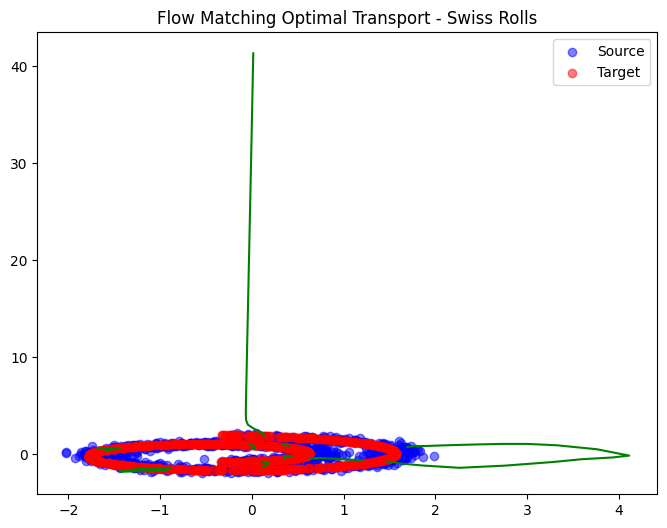

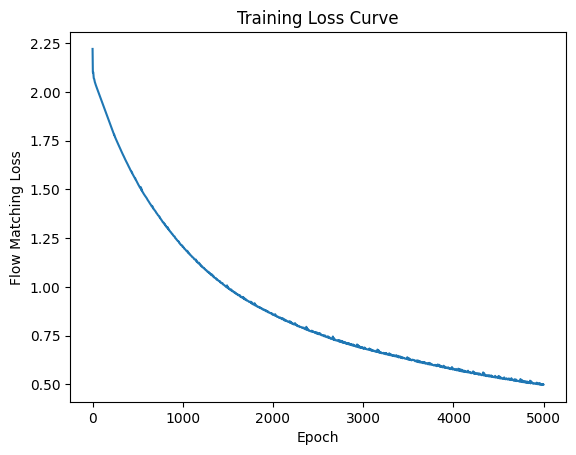

In [2]:
import jax
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll
import haiku as hk


# 1. Generate Swiss Roll Datasets
def create_swiss_roll(n_samples=1000, noise=0.0):
    data, _ = make_swiss_roll(n_samples=n_samples, noise=noise)
    data = data[:, [0, 2]]  # Only take (x, z) to make it 2D
    data = (data - data.mean(0)) / data.std(0)
    return data

key = jax.random.PRNGKey(0)
source = create_swiss_roll(n_samples=1024, noise=1)
target = create_swiss_roll(n_samples=1024)

# 2. Define Neural Network for Vector Field
def flow_network_fn(x):
    mlp = hk.Sequential([
        hk.Linear(128), jax.nn.relu,
        hk.Linear(128), jax.nn.relu,
        hk.Linear(2)  # output vector field same dimension
    ])
    return mlp(x)

flow_network = hk.transform(flow_network_fn)

# Initialize network parameters
sample_input = jnp.ones((1, 2))
params = flow_network.init(key, sample_input)

# Optimizer
optimizer = optax.adam(1e-3)
opt_state = optimizer.init(params)

# 3. Define Flow Matching Loss
def loss_fn(params, x0, x1, t, noise_std=0.1):
    """Flow Matching Loss."""
    mean = (1.0 - t) * x0 + t * x1
    noise = noise_std * jax.random.normal(jax.random.PRNGKey(42), mean.shape)
    x_t = mean + noise
    true_velocity = x1 - x0
    pred_velocity = flow_network.apply(params, None, x_t)
    loss = jnp.mean(jnp.square(pred_velocity - true_velocity))
    return loss

# 4. Training Loop
n_epochs = 5000
batch_size = 256
losses = []

@jax.jit
def train_step(params, opt_state, x0_batch, x1_batch, t_batch):
    loss, grads = jax.value_and_grad(loss_fn)(params, x0_batch, x1_batch, t_batch)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

for epoch in range(n_epochs):
    # Randomly sample batches
    idx = jax.random.choice(key, source.shape[0], (batch_size,), replace=False)
    x0_batch = source[idx]
    x1_batch = target[idx]
    t_batch = jax.random.uniform(key, (batch_size, 1))
    
    params, opt_state, loss = train_step(params, opt_state, x0_batch, x1_batch, t_batch)
    if epoch % 500 == 0:
        print(f"Epoch {epoch}: Loss = {loss:.4f}")
    losses.append(loss)

# 5. Visualization: Flow Paths
def plot_flow_matching(params, source, target, n_flows=10, steps=20):
    idx = jax.random.choice(key, source.shape[0], (n_flows,), replace=False)
    x = source[idx]
    trajectories = [x]
    dt = 1.0 / steps
    for _ in range(steps):
        t_val = jnp.ones((x.shape[0], 1)) * (_ * dt)
        v = flow_network.apply(params, None, x)
        x = x + v * dt
        trajectories.append(x)
    
    trajectories = jnp.stack(trajectories, axis=1)
    
    # Plot
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(source[:, 0], source[:, 1], color='blue', alpha=0.5, label='Source')
    ax.scatter(target[:, 0], target[:, 1], color='red', alpha=0.5, label='Target')
    for i in range(n_flows):
        ax.plot(trajectories[i, :, 0], trajectories[i, :, 1], color='green')
    ax.legend()
    ax.set_title('Flow Matching Optimal Transport - Swiss Rolls')
    plt.show()

plot_flow_matching(params, source, target)

# 6. Plot Loss Curve
plt.figure()
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Flow Matching Loss')
plt.title('Training Loss Curve')
plt.show()
